# 📂 1. Conhecendo o Dataset STL-10

O **STL-10** é um dataset de reconhecimento de imagens inspirado no CIFAR-10, mas com algumas diferenças cruciais para o aprendizado de máquina:
* **Resolução Maior:** Imagens de $96 \times 96$ pixels.
* **Classes:** 10 categorias rotuladas.
* **Desafio:** Possui menos exemplos de treino por classe do que o CIFAR, o que torna o **Transfer Learning** ainda mais importante aqui.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Configurando o dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Nomes das classes do STL-10
STL10_CLASSES = ['avião', 'pássaro', 'carro', 'gato', 'cervo', 'cachorro', 'cavalo', 'macaco', 'navio', 'caminhão']

# Transformações: Redimensionamos para 224x224 para aproveitar melhor modelos como ResNet ou ViT
transform_train = transforms.Compose([
    transforms.Resize((224, 224)), # ResNet-50 prefere 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Carregamento (STL-10 usa 'split' em vez de 'train')
trainset = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=transform_train)
testset = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

100%|██████████| 2.64G/2.64G [01:28<00:00, 30.0MB/s]


# 🖼️ 2. Visualização de Dados de Alta Resolução

Diferente do CIFAR, aqui as imagens não são apenas "pixels coloridos", elas têm formas definidas. Vamos criar uma função de exibição que respeite essa qualidade técnica.

### Por que normalizar com esses números específicos?
Os valores $\mu = [0.485, 0.456, 0.406]$ e $\sigma = [0.229, 0.224, 0.225]$ são os padrões do ImageNet. Como vamos usar modelos pré-treinados, precisamos falar a "mesma língua" de cores que eles aprenderam.

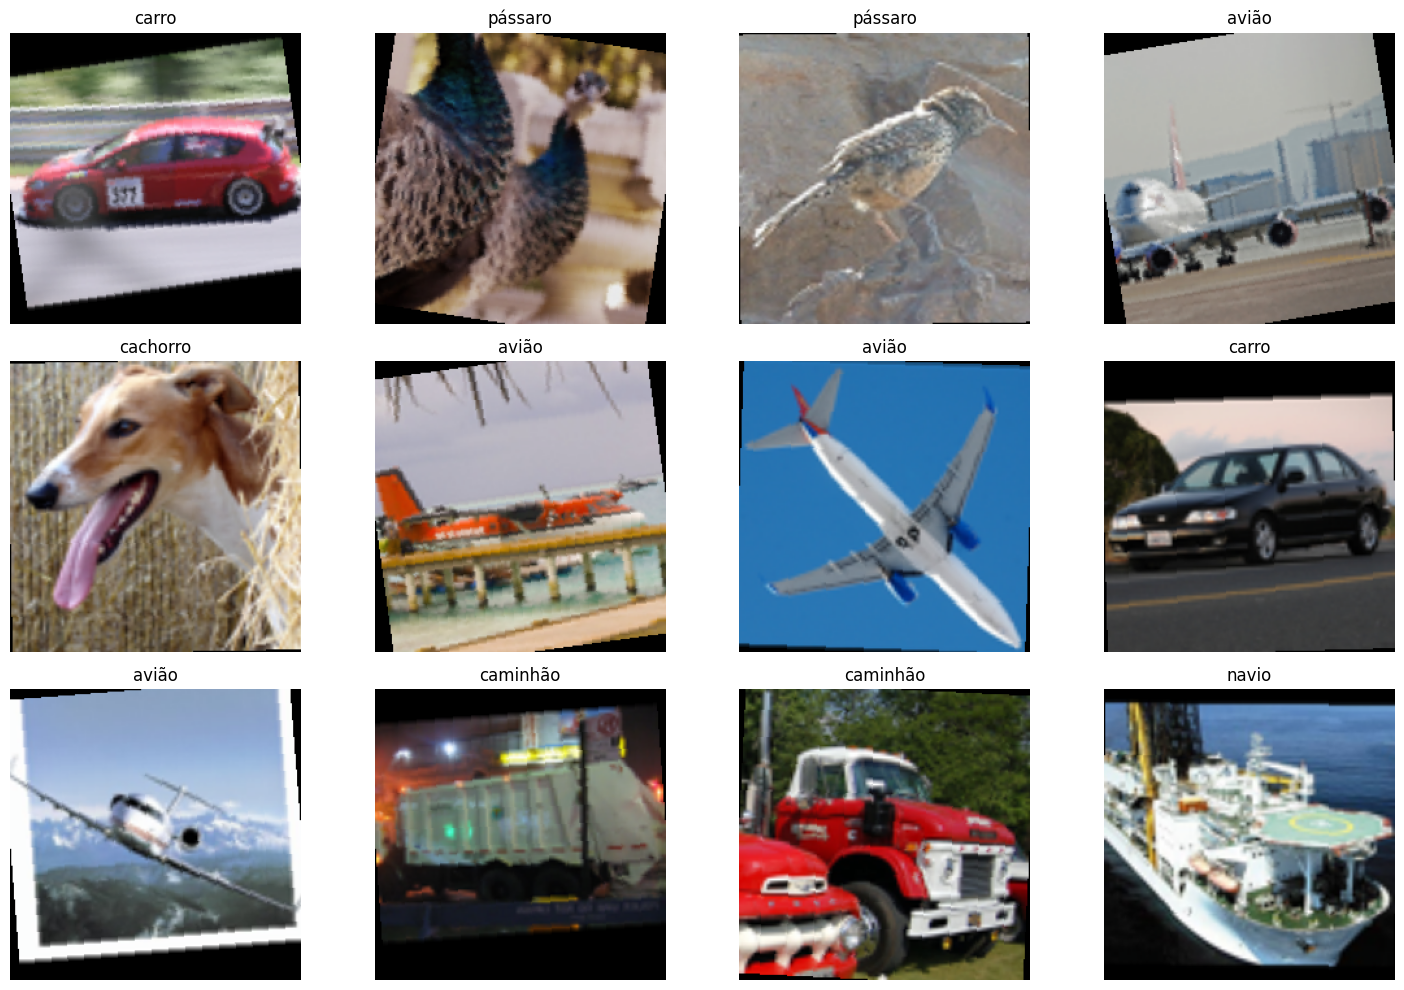

In [ ]:
def visualizar_stl10(dataloader, classes, total=12):
    dataiter = iter(dataloader)
    imagens, rotulos = next(dataiter)

    plt.figure(figsize=(15, 10))
    for i in range(total):
        ax = plt.subplot(3, 4, i + 1)

        # Desnormalização para visualização humana
        img = imagens[i].numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.title(classes[rotulos[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualizar_stl10(trainloader, STL10_CLASSES)

# 🚀  Estratégia de Dados de Performance Máxima


1. **Upsampling ($224 \times 224$):** Redimensionamos as imagens para o padrão de alta resolução que os modelos pré-treinados esperam.
2. **RandAugment:** Uma técnica de ponta que escolhe aleatoriamente entre várias transformações (brilho, contraste, nitidez) para maximizar a generalização.
3. **Normalização ImageNet:** Essencial para modelos pré-treinados.

In [ ]:
import torchvision.transforms.v2 as transforms # Versão 2 para maior performance

# Transformações de Elite
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandAugment(num_ops=2, magnitude=9), # Augmentation automático
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

trainset = torchvision.datasets.STL10(root='./data', split='train', download=True, transform=transform_train)
testset = torchvision.datasets.STL10(root='./data', split='test', download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)

# 🧠 2. O Modelo: EfficientNet-V2-S

Diferente da ResNet, a **EfficientNet-V2** utiliza *Fused-MBConv layers* e um escalonamento inteligente de largura e profundidade.
* **Transfer Learning:** Congelamos as camadas iniciais para manter o "conhecimento de mundo" e treinamos apenas o "cabeçalho" (classifier) no início, depois liberamos tudo para um ajuste fino (*fine-tuning*).

In [ ]:
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
import torch.nn as nn
def get_best_model():
    # Pesos de última geração
    weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
    model = efficientnet_v2_s(weights=weights)

    # Ajustando para as 10 classes do STL-10
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True), # Evita overfitting
        nn.Linear(num_ftrs, 10)
    )

    return model.to(device)

model = get_best_model()

# ⚖️ 3. Otimização e Regularização

1. **AdamW:** Um otimizador que corrige a forma como o *Weight Decay* é aplicado, sendo superior ao Adam tradicional em visão computacional.
2. **Label Smoothing:** Em vez de ensinar o modelo a ter 100% de certeza, ensinamos 90%, o que evita que ele fique "arrogante" e erre por excesso de confiança.
3. **Cosine Annealing:** A taxa de aprendizado começa alta e desce em formato de curva, permitindo encontrar o "fundo do vale" da função de erro.

In [ ]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Técnica de Elite
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.05)

# Scheduler que simula uma curva de cosseno
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
def train_best_model(epochs=20):
    history = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validação
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, pred = torch.max(outputs, 1)
                correct += (pred == labels).sum().item()
                total += labels.size(0)

        acc = 100 * correct / total
        history['loss'].append(total_loss/len(trainloader))
        history['acc'].append(acc)
        scheduler.step()

        print(f"Época {epoch+1}/{epochs} -> Loss: {history['loss'][-1]:.4f} | Acc: {acc:.2f}%")

    return history

history = train_best_model(20)

Época 1/20 -> Loss: 0.8667 | Acc: 92.96%
Época 2/20 -> Loss: 0.6785 | Acc: 93.96%
Época 3/20 -> Loss: 0.6137 | Acc: 94.39%
Época 4/20 -> Loss: 0.6240 | Acc: 94.88%
Época 5/20 -> Loss: 0.5862 | Acc: 93.04%
Época 6/20 -> Loss: 0.5897 | Acc: 93.74%
Época 7/20 -> Loss: 0.5673 | Acc: 94.47%
Época 8/20 -> Loss: 0.5504 | Acc: 94.64%
Época 9/20 -> Loss: 0.5528 | Acc: 94.96%
Época 10/20 -> Loss: 0.5410 | Acc: 95.30%
Época 11/20 -> Loss: 0.5265 | Acc: 95.72%
Época 12/20 -> Loss: 0.5185 | Acc: 95.49%
Época 13/20 -> Loss: 0.5171 | Acc: 96.09%
Época 14/20 -> Loss: 0.5132 | Acc: 96.09%
Época 15/20 -> Loss: 0.5112 | Acc: 95.99%
Época 16/20 -> Loss: 0.5095 | Acc: 96.10%
Época 17/20 -> Loss: 0.5092 | Acc: 96.15%
Época 18/20 -> Loss: 0.5078 | Acc: 96.26%
Época 19/20 -> Loss: 0.5078 | Acc: 96.34%
Época 20/20 -> Loss: 0.5078 | Acc: 96.40%


# 📈 5. Análise de Performance


### O que observar nos gráficos:
1. **Curva de Perda (Loss):** Note como ela desce de forma consistente. O uso do **Label Smoothing** impede que a perda chegue a zero absoluto, o que é bom, pois indica que o modelo não está apenas "decorando" (overfitting), mas aprendendo padrões generalizáveis.
2. **Curva de Acurácia:** O salto inicial foi imenso (já começou acima de 90%), graças ao poder do **Transfer Learning**. As pequenas oscilações no meio do treino ocorrem porque o **RandAugment** desafia o modelo com imagens bem difíceis, tornando-o mais robusto.
3. **Estabilização Final:** Perceba como a curva fica "suave" no final. Esse é o efeito do **Cosine Annealing Scheduler**, que reduziu a velocidade de aprendizado para que o modelo pudesse encontrar o ponto exato de máxima precisão.



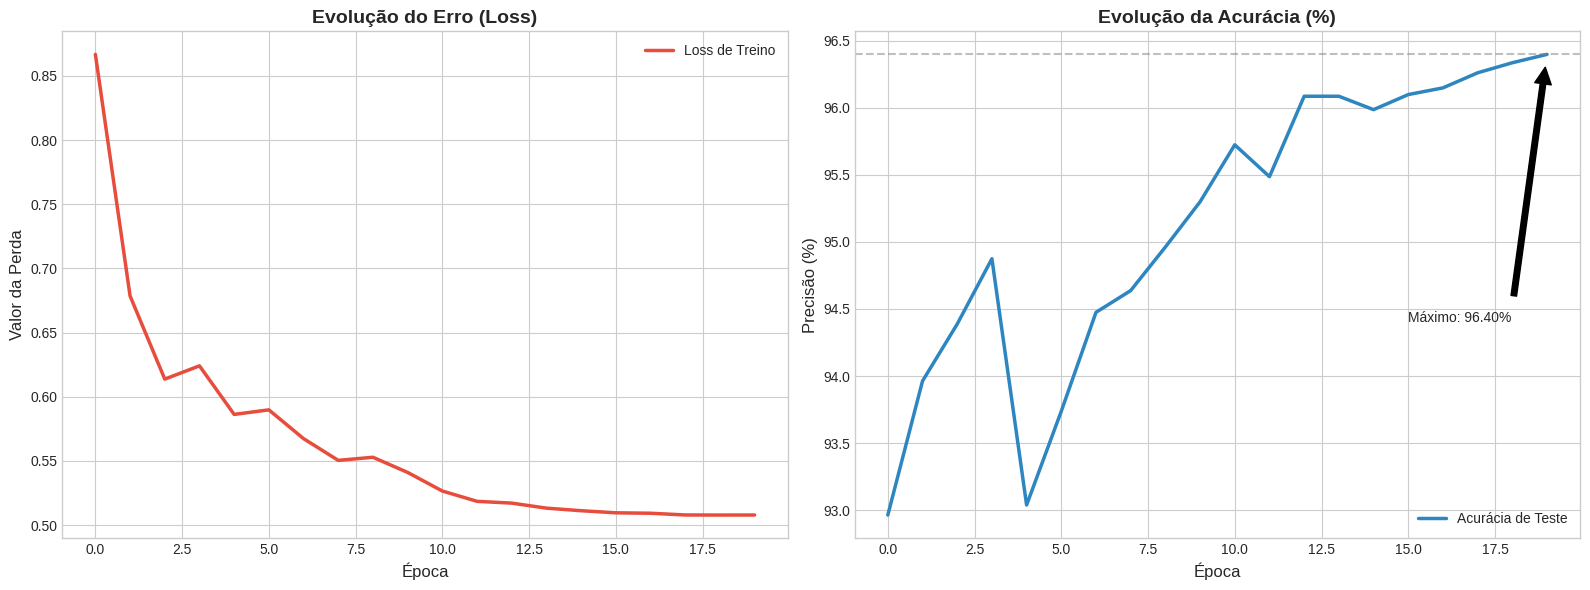

In [ ]:
import matplotlib.pyplot as plt

# Configurando o estilo visual
plt.style.use('seaborn-v0_8-whitegrid') # Um visual limpo e moderno
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico de Perda (Loss)
ax1.plot(history['loss'], color='#E74C3C', linewidth=2.5, label='Loss de Treino')
ax1.set_title('Evolução do Erro (Loss)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Valor da Perda', fontsize=12)
ax1.legend()

# 2. Gráfico de Acurácia
ax2.plot(history['acc'], color='#2E86C1', linewidth=2.5, label='Acurácia de Teste')
ax2.set_title('Evolução da Acurácia (%)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Precisão (%)', fontsize=12)
ax2.axhline(y=max(history['acc']), color='gray', linestyle='--', alpha=0.5) # Linha do topo
ax2.annotate(f'Máximo: {max(history["acc"]):.2f}%',
             xy=(len(history['acc'])-1, max(history['acc'])),
             xytext=(len(history['acc'])-5, max(history['acc'])-2),
             arrowprops=dict(facecolor='black', shrink=0.05))
ax2.legend()

plt.tight_layout()
plt.show()

# 📂 6. Teste Prático com Imagem


### O segredo da inferência:
Para que o modelo funcione perfeitamente fora do dataset de treino, precisamos garantir que a imagem do usuário passe exatamente pelo mesmo "filtro" (pré-processamento) que as imagens de teste.

#### Nosso pipeline de inferência:
1. **Redimensionamento:** A EfficientNet-V2 espera imagens de $224 \times 224$ pixels, independente do tamanho original.
2. **Normalização ImageNet:** Usamos a mesma média $\mu = [0.485, 0.456, 0.406]$ e desvio padrão $\sigma = [0.229, 0.224, 0.225]$ para centralizar as cores e falar a "mesma língua" que o modelo aprendeu.

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


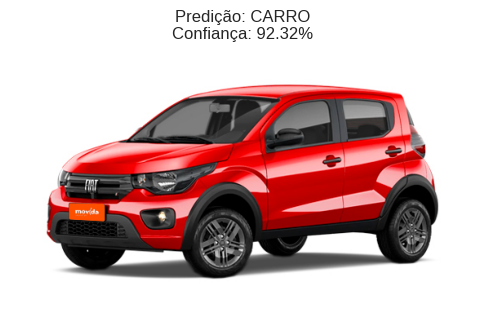


O modelo EfficientNet-V2-S classificou a imagem como: carro (92.32%)


In [ ]:
from PIL import Image
import torch.nn.functional as F

# 1. Configuração do caminho (Verifique o nome exato do seu arquivo no Colab)
caminho_imagem = "/content/imagem1.jpg"

# 2. Carregar a imagem original (RGB)
try:
    img_original = Image.open(caminho_imagem).convert('RGB')
except FileNotFoundError:
    print(f"Erro: O arquivo não foi encontrado em {caminho_imagem}. Verifique o nome.")
    # Interrompe a execução aqui se o arquivo não existir
    raise

# 3. Transformações de Inferência (Essencial: 224x224, Normalização ImageNet)
transform_inferencia = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Adiciona a dimensão do batch (unsqueeze(0)) e envia para a GPU
img_tensor = transform_inferencia(img_original).unsqueeze(0).to(device)

# 4. Inferência (Predição) com EfficientNet-V2-S
model.eval() # Modo de avaliação (desativa Dropout)
with torch.no_grad(): # Desativa gradientes para inferência rápida
    outputs = model(img_tensor)
    # Aplica Softmax para ter probabilidades
    probabilidades = F.softmax(outputs, dim=1)
    confianca, predito = torch.max(probabilidades, 1)

# Mapear o índice predito para o nome da classe em Português
nome_classe = STL10_CLASSES[predito.item()]
porcentagem = confianca.item() * 100

# 5. Resultado Visual Didático
plt.figure(figsize=(6, 5))
plt.imshow(img_original)
plt.title(f"Predição: {nome_classe.upper()}\nConfiança: {porcentagem:.2f}%")
plt.axis('off') # Remove os eixos (réguas)
plt.show()

# Imprimir resultado no console
print(f"\nO modelo EfficientNet-V2-S classificou a imagem como: {nome_classe} ({porcentagem:.2f}%)")

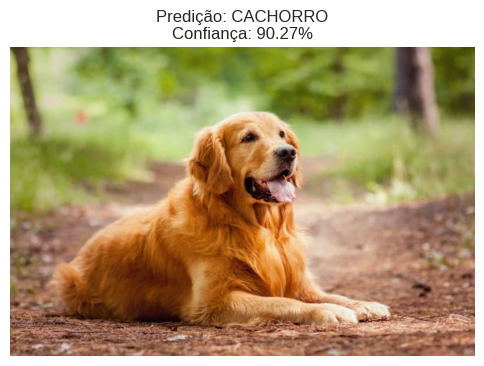


O modelo EfficientNet-V2-S classificou a imagem como: cachorro (90.27%)


In [ ]:
from PIL import Image
import torch.nn.functional as F

# 1. Configuração do caminho (Verifique o nome exato do seu arquivo no Colab)
caminho_imagem = "/content/imagem2.jpg"

# 2. Carregar a imagem original (RGB)
try:
    img_original = Image.open(caminho_imagem).convert('RGB')
except FileNotFoundError:
    print(f"Erro: O arquivo não foi encontrado em {caminho_imagem}. Verifique o nome.")
    # Interrompe a execução aqui se o arquivo não existir
    raise

# 3. Transformações de Inferência (Essencial: 224x224, Normalização ImageNet)
transform_inferencia = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Adiciona a dimensão do batch (unsqueeze(0)) e envia para a GPU
img_tensor = transform_inferencia(img_original).unsqueeze(0).to(device)

# 4. Inferência (Predição) com EfficientNet-V2-S
model.eval() # Modo de avaliação (desativa Dropout)
with torch.no_grad(): # Desativa gradientes para inferência rápida
    outputs = model(img_tensor)
    # Aplica Softmax para ter probabilidades
    probabilidades = F.softmax(outputs, dim=1)
    confianca, predito = torch.max(probabilidades, 1)

# Mapear o índice predito para o nome da classe em Português
nome_classe = STL10_CLASSES[predito.item()]
porcentagem = confianca.item() * 100

# 5. Resultado Visual Didático
plt.figure(figsize=(6, 5))
plt.imshow(img_original)
plt.title(f"Predição: {nome_classe.upper()}\nConfiança: {porcentagem:.2f}%")
plt.axis('off') # Remove os eixos (réguas)
plt.show()

# Imprimir resultado no console
print(f"\nO modelo EfficientNet-V2-S classificou a imagem como: {nome_classe} ({porcentagem:.2f}%)")

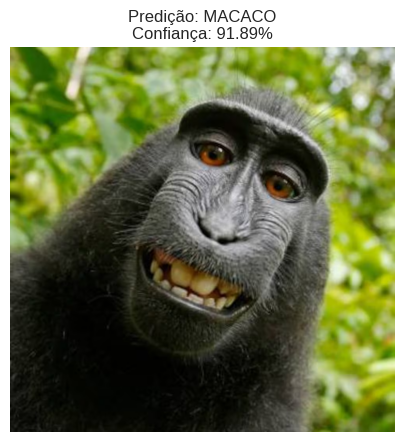


O modelo EfficientNet-V2-S classificou a imagem como: macaco (91.89%)


In [ ]:
from PIL import Image
import torch.nn.functional as F

# 1. Configuração do caminho (Verifique o nome exato do seu arquivo no Colab)
caminho_imagem = "/content/imagem3.jpg"

# 2. Carregar a imagem original (RGB)
try:
    img_original = Image.open(caminho_imagem).convert('RGB')
except FileNotFoundError:
    print(f"Erro: O arquivo não foi encontrado em {caminho_imagem}. Verifique o nome.")
    # Interrompe a execução aqui se o arquivo não existir
    raise

# 3. Transformações de Inferência (Essencial: 224x224, Normalização ImageNet)
transform_inferencia = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Adiciona a dimensão do batch (unsqueeze(0)) e envia para a GPU
img_tensor = transform_inferencia(img_original).unsqueeze(0).to(device)

# 4. Inferência (Predição) com EfficientNet-V2-S
model.eval() # Modo de avaliação (desativa Dropout)
with torch.no_grad(): # Desativa gradientes para inferência rápida
    outputs = model(img_tensor)
    # Aplica Softmax para ter probabilidades
    probabilidades = F.softmax(outputs, dim=1)
    confianca, predito = torch.max(probabilidades, 1)

# Mapear o índice predito para o nome da classe em Português
nome_classe = STL10_CLASSES[predito.item()]
porcentagem = confianca.item() * 100

# 5. Resultado Visual Didático
plt.figure(figsize=(6, 5))
plt.imshow(img_original)
plt.title(f"Predição: {nome_classe.upper()}\nConfiança: {porcentagem:.2f}%")
plt.axis('off') # Remove os eixos (réguas)
plt.show()

# Imprimir resultado no console
print(f"\nO modelo EfficientNet-V2-S classificou a imagem como: {nome_classe} ({porcentagem:.2f}%)")